# Fair ML Pipeline — Demo

End-to-end walkthrough: load data → inject synthetic bias → audit → mitigate → compare results.

**Sensitive attribute:** `Gender`  
**Target:** `Loan_Approval_Status`  
**Dataset:** `../data/loan_dataset.csv`

---
## 0. Imports & Setup

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

# Project modules
from measurements.analyzer import FairnessAnalyzer
from pipeline.detection_engine import BiasDetectionEngine
from pipeline.fair_transformers import InstanceReweighting, CorrelationSuppressor, DisparateImpactRemover
from pipeline.pipeline_framework import FairPipelineBuilder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports OK.')

All imports OK.


---
## 1. Load Dataset

In [8]:
df_raw = pd.read_csv('../data/loan_dataset.csv')

---
## 2. Inject Synthetic Bias

We add calibrated noise to the **Female** subgroup to simulate a biased dataset:

- **Income noise** — Gaussian perturbation that slightly reduces female income on average
- **Credit Score noise** — small downward shift for female applicants
- **Label flip** — a fraction of female approvals are flipped to rejections

This mimics the kind of historical bias often present in real-world lending data.

In [9]:
df = df_raw.copy()
df.dropna(inplace=True)

female_mask = df['Gender'] == 'Female'
n_female = female_mask.sum()

# --- 2a. Income noise: mean shift of -8% + Gaussian noise
income_noise = np.random.normal(loc=-0.08, scale=0.05, size=n_female)
df.loc[female_mask, 'Annual_Income'] = (
    df.loc[female_mask, 'Annual_Income'] * (1 + income_noise)
).clip(lower=0)

# --- 2b. Credit Score noise: small downward shift
credit_noise = np.random.normal(loc=-15, scale=8, size=n_female)
df.loc[female_mask, 'Credit_Score'] = (
    df.loc[female_mask, 'Credit_Score'] + credit_noise
).clip(lower=300, upper=850)

# --- 2c. Label flip: 12% of female approvals → rejection
female_approved_idx = df[(female_mask) & (df['Loan_Approval_Status'] == 1)].index
flip_n = int(len(female_approved_idx) * 0.12)
flip_idx = np.random.choice(female_approved_idx, size=flip_n, replace=False)
df.loc[flip_idx, 'Loan_Approval_Status'] = 0

print('Bias injection complete.')
print(f'  Income shift  (Female vs Male): '
      f"{df.loc[female_mask,'Annual_Income'].mean():.0f} vs {df.loc[~female_mask,'Annual_Income'].mean():.0f}")
print(f'  Credit shift  (Female vs Male): '
      f"{df.loc[female_mask,'Credit_Score'].mean():.1f} vs {df.loc[~female_mask,'Credit_Score'].mean():.1f}")
print(f'  Approval rate (Female vs Male): '
      f"{df.loc[female_mask,'Loan_Approval_Status'].mean():.3f} vs {df.loc[~female_mask,'Loan_Approval_Status'].mean():.3f}")
print(f'  Label flips applied: {flip_n}')

Bias injection complete.
  Income shift  (Female vs Male): 77175 vs 83302
  Credit shift  (Female vs Male): 664.0 vs 677.3
  Approval rate (Female vs Male): 0.566 vs 0.640
  Label flips applied: 2007


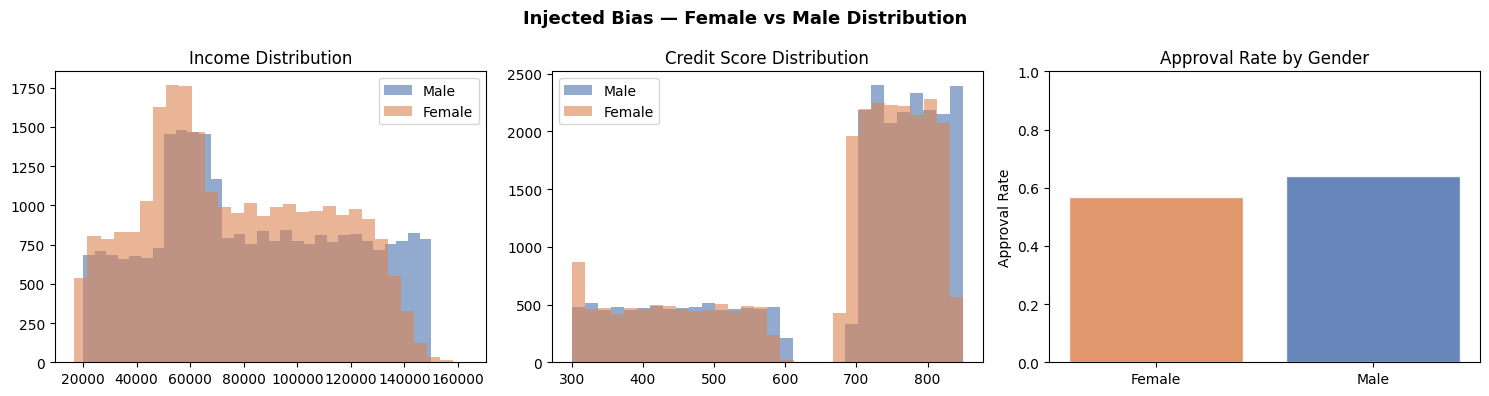

In [10]:
# Visualise injected bias
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Injected Bias — Female vs Male Distribution', fontsize=13, fontweight='bold')

for gender, color in [('Male', '#4C72B0'), ('Female', '#DD8452')]:
    subset = df[df['Gender'] == gender]
    axes[0].hist(subset['Annual_Income'], bins=30, alpha=0.6, label=gender, color=color)
    axes[1].hist(subset['Credit_Score'], bins=30, alpha=0.6, label=gender, color=color)

approval_rates = df.groupby('Gender')['Loan_Approval_Status'].mean()
axes[2].bar(approval_rates.index, approval_rates.values,
            color=['#DD8452', '#4C72B0',], alpha=0.85, edgecolor='white')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Approval Rate')

axes[0].set_title('Income Distribution')
axes[1].set_title('Credit Score Distribution')
axes[2].set_title('Approval Rate by Gender')

for ax in axes[:2]:
    ax.legend()

plt.tight_layout()
plt.savefig('bias_injection.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Bias Audit — FairnessAnalyzer

We use `FairnessAnalyzer` to get a structured audit with confidence intervals before training any model.

In [11]:
analyzer = FairnessAnalyzer(df=df)
analyzer.set_config(
    target_col='Loan_Approval_Status',
    sensitive_col='Gender',
    positive_label=1
)

# Age binning for intersectional analysis later
analyzer.bin_column(
    column_name='Age',
    bins=[0, 25, 35, 45, 55, 65, float('inf')],
    labels=['0-25', '26-35', '36-45', '46-55', '56-65', '65+'],
    new_column_name='Age_Group'
)

print('FairnessAnalyzer configured.')

FairnessAnalyzer ready — 52,000 rows loaded.
'Age' → 'Age_Group' (set_as_sensitive=False).
FairnessAnalyzer configured.


In [12]:
# Selection rate disparity with bootstrap CI
audit = analyzer.get_fairness_audit(n_bootstrap=300)
print('=== Fairness Audit ===')
print(audit)

=== Fairness Audit ===
FairnessResult(Selection Rate Disparity)
  value              = 0.0732
  95% CI             = (0.0651, 0.0800)
  effect_size        = 0.8855308031580451
  sample_sizes       = {'Male': 26011, 'Female': 25989}



In [13]:
# Classification metrics — Fairlearn
fl_results = analyzer.calculate_classification_metrics(engine='fairlearn')
print('=== Fairlearn Metrics ===')
for name, result in fl_results.items():
    ci = result.confidence_interval
    
    eff_size_str = f"{result.effect_size:.4f}" if result.effect_size is not None else "N/A"
    
    print(f'{name:35s}  value={result.value:+.4f}  '
          f'CI=({ci[0]:+.4f}, {ci[1]:+.4f})  '
          f'effect_size={eff_size_str}')

=== Fairlearn Metrics ===
demographic_parity_difference        value=+0.0732  CI=(+0.0645, +0.0819)  effect_size=0.8855
equalized_odds_difference            value=+0.0000  CI=(+0.0000, +0.0000)  effect_size=N/A


In [14]:
# Intersectional audit: Gender × Age_Group
inter_df = analyzer.intersectional_audit(
    column_names=['Gender', 'Age_Group'],
    apply_fdr_correction=True
)
print('=== Intersectional Audit (Gender × Age_Group) ===')
inter_df.sort_values('p_value_bh_corrected').head(10)

=== Intersectional Audit (Gender × Age_Group) ===


,group,n,selection_rate,global_rate,ci_lower,ci_upper,risk_ratio,p_value_proxy,p_value_bh_corrected,significant_after_correction
5,Male_46-55,4344,0.607965,0.603058,0.593011,0.620276,1.008137,0.0,0.0,True
0,Male_36-45,8947,0.733766,0.603058,0.724451,0.742431,1.216742,1.0,1.0,False
2,Female_26-35,8783,0.643630,0.603058,0.633918,0.653450,1.067277,1.0,1.0,False
1,Female_36-45,8888,0.641764,0.603058,0.631321,0.652107,1.064184,1.0,1.0,False
3,Male_26-35,8665,0.727986,0.603058,0.718766,0.737396,1.207158,1.0,1.0,False
4,Female_46-55,4372,0.539570,0.603058,0.524307,0.553823,0.894724,1.0,1.0,False
6,Male_0-25,1987,0.412179,0.603058,0.391149,0.436022,0.683482,1.0,1.0,False
7,Female_0-25,1902,0.369611,0.603058,0.348337,0.391518,0.612895,1.0,1.0,False
8,Female_56-65,1487,0.146604,0.603058,0.129994,0.166618,0.243101,1.0,1.0,False
9,Male_56-65,1479,0.158215,0.603058,0.140630,0.174877,0.262355,1.0,1.0,False


In [15]:
# Aequitas disparity table
aequitas_df = analyzer.get_aequitas_metrics()
print('=== Aequitas Disparity Metrics ===')
aequitas_df

=== Aequitas Disparity Metrics ===


,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,...,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,0,binary 0/1,31359,Gender,Female,1.0,1.0,1.0,0.0,0.0,...,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,0,binary 0/1,31359,Gender,Male,1.0,1.0,1.0,0.0,0.0,...,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male


In [16]:
# Visualise audit results
analyzer.generate_report_visualizations(fl_results, output_path='fairness_audit.png')
plt.show()

✓ Visualisation saved to 'fairness_audit.png'.


---
## 4. Detection Engine — Raw Dataset Scan

`BiasDetectionEngine` audits representation, statistical disparity, and proxy correlations before building any pipeline.

In [17]:
engine = BiasDetectionEngine(
    df=df_raw,
    sensitive_cols=['Gender'],
    benchmarks={'Male': 0.5, 'Female': 0.5},
)

report = engine.run()

print('=== Bias Detection Report ===')
print(report.summary)

[BiasDetectionEngine] Report saved → bias_report.json
=== Bias Detection Report ===
{'representation_flags': 0, 'disparity_flags': 1, 'proxy_flags': 0, 'total_flags': 1, 'overall_risk': 'LOW'}


In [18]:
print('Representation bias:')
for sensitive_col, findings in report.representation.items():
    print(f"\nColonna: {sensitive_col}")
    for finding in findings:
        print(f'  {finding.group:10s}: observed={finding.observed_rate:.3f}  '
              f'benchmark={finding.benchmark_rate:.3f}  gap={finding.absolute_gap:+.3f}  '
              f'[Flag: {finding.flagged}]')

Representation bias:

Colonna: Gender
  Male      : observed=0.500  benchmark=0.500  gap=+0.000  [Flag: False]
  Female    : observed=0.500  benchmark=0.500  gap=+0.000  [Flag: False]


In [19]:
print('Top proxy correlations:')
proxy_df = pd.DataFrame(report.proxy)
if not proxy_df.empty:
    display(proxy_df.sort_values('correlation', ascending=False).head(8))
else:
    print("No proxy correlations found.")

Top proxy correlations:


,feature,sensitive_attribute,method,correlation,flagged
18,Loan_Purpose,Gender,cramers_v,0.0094,False
0,Applicant_ID,Gender,point_biserial,0.0089,False
24,Default_Risk,Gender,point_biserial,0.0081,False
9,Annual_Income,Gender,point_biserial,0.0080,False
7,Residential_Status,Gender,cramers_v,0.0076,False
16,Loan_Amount_Requested,Gender,point_biserial,0.0076,False
8,City/Town,Gender,cramers_v,0.0073,False
21,Co-Applicant,Gender,cramers_v,0.0069,False


---
## 5. Baseline Model — No Mitigation

Train a logistic regression on the biased data to establish a reference point.

In [20]:
FEATURE_COLS = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount_Requested', 'Employment_Status']
TARGET_COL   = 'Loan_Approval_Status'
SENSITIVE    = 'Gender'

# Encode categorical columns
df_enc = pd.get_dummies(df[FEATURE_COLS + [TARGET_COL, SENSITIVE]], drop_first=True)

X = df_enc.drop(columns=[TARGET_COL])
y = df_enc[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print('=== Baseline Model ===')
print(classification_report(y_test, y_pred_baseline))

=== Baseline Model ===
              precision    recall  f1-score   support

           0       0.85      0.64      0.73      4128
           1       0.80      0.93      0.86      6272

    accuracy                           0.81     10400
   macro avg       0.82      0.78      0.79     10400
weighted avg       0.82      0.81      0.81     10400



In [21]:
# Baseline fairness metrics
gender_col = 'Gender_Male' if 'Gender_Male' in X_test.columns else [c for c in X_test.columns if 'Gender' in c][0]

test_df_with_pred = X_test.copy()
test_df_with_pred['y_true'] = y_test.values
test_df_with_pred['y_pred'] = y_pred_baseline
test_df_with_pred['Gender'] = test_df_with_pred[gender_col].map({1: 'Male', 0: 'Female'})

print('Approval rates by gender (baseline predictions):')
print(test_df_with_pred.groupby('Gender')['y_pred'].mean().round(3))

approval_by_gender = test_df_with_pred.groupby('Gender')['y_pred'].mean()
di_baseline = approval_by_gender.min() / approval_by_gender.max()
print(f'\nDisparate Impact (baseline): {di_baseline:.4f}  (threshold: 0.80)')

Approval rates by gender (baseline predictions):
Series([], Name: y_pred, dtype: float64)

Disparate Impact (baseline): nan  (threshold: 0.80)


---
## 6. Mitigation — Individual Transformers

We test each transformer from `fair_transformers.py` individually.

### 6a. CorrelationSuppressor — Remove Proxy Features

In [22]:
suppressor = CorrelationSuppressor(
    sensitive_col=SENSITIVE,
    threshold=0.25
)

X_train_num = df_enc.drop(columns=[TARGET_COL]).loc[X_train.index]
X_test_num  = df_enc.drop(columns=[TARGET_COL]).loc[X_test.index]

X_train_num = X_train_num.rename(columns={'Gender_Male': 'Gender'})
X_test_num  = X_test_num.rename(columns={'Gender_Male': 'Gender'})

X_train_sup = suppressor.fit_transform(X_train_num)
X_test_sup  = suppressor.transform(X_test_num)

print(f'Features before suppression : {X_train_num.shape[1]}')
print(f'Features after suppression  : {X_train_sup.shape[1]}')
print(f'Dropped features            : {suppressor.dropped_features_}')

Features before suppression : 7
Features after suppression  : 6
Dropped features            : []


### 6b. DisparateImpactRemover — Quantile Repair

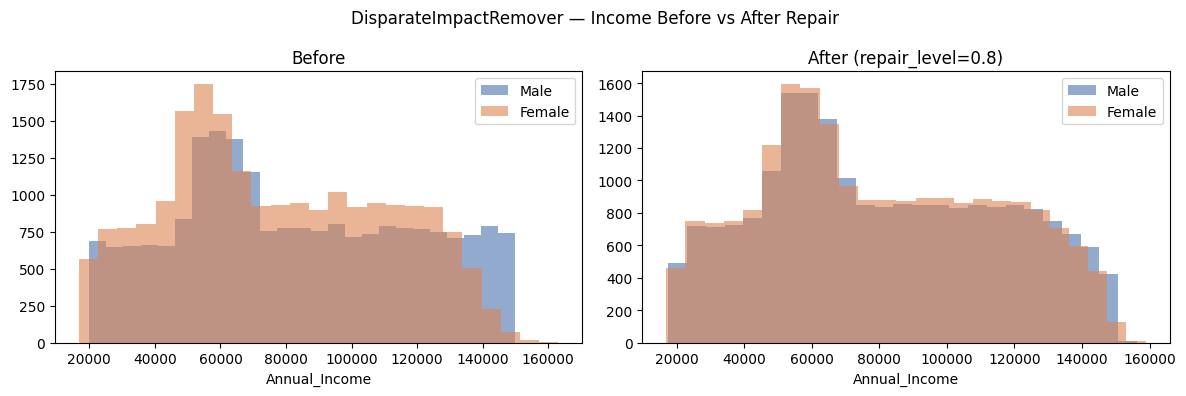

In [23]:
remover = DisparateImpactRemover(
    sensitive_col=SENSITIVE,
    repair_level=0.8,
    features_to_repair=['Annual_Income', 'Credit_Score']
)

X_train_rem = remover.fit_transform(
    df[FEATURE_COLS + [SENSITIVE]].loc[X_train.index]
)

# Compare income distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('DisparateImpactRemover — Income Before vs After Repair', fontsize=12)

for gender, color in [('Male', '#4C72B0'), ('Female', '#DD8452')]:
    mask_train = df.loc[X_train.index, 'Gender'] == gender
    axes[0].hist(df.loc[X_train.index][mask_train]['Annual_Income'], bins=25,
                 alpha=0.6, label=gender, color=color)
    axes[1].hist(X_train_rem[X_train_rem['Gender'] == gender]['Annual_Income'], bins=25,
                 alpha=0.6, label=gender, color=color)

axes[0].set_title('Before')
axes[1].set_title('After (repair_level=0.8)')
for ax in axes:
    ax.legend()
    ax.set_xlabel('Annual_Income')

plt.tight_layout()
plt.savefig('disparate_impact_repair.png', dpi=120, bbox_inches='tight')
plt.show()

### 6c. InstanceReweighting — Sample Weights

In [24]:
reweighter = InstanceReweighting(sensitive_col=SENSITIVE, target_col=TARGET_COL)

train_full = df.loc[X_train.index][FEATURE_COLS + [SENSITIVE, TARGET_COL]]
reweighter.fit(train_full)

print('Sample weight statistics:')
weights = reweighter.sample_weight_
print(f'  mean  : {weights.mean():.4f}  (expected ≈ 1.0)')
print(f'  min   : {weights.min():.4f}')
print(f'  max   : {weights.max():.4f}')
print(f'  sum   : {weights.sum():.1f}  (n = {len(weights)})')

# Train weighted model
mitigated = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
mitigated.fit(X_train, y_train, sample_weight=weights)
y_pred_mitigated = mitigated.predict(X_test)

print('\n=== Mitigated Model (InstanceReweighting) ===')
print(classification_report(y_test, y_pred_mitigated))

Sample weight statistics:
  mean  : 1.0000  (expected ≈ 1.0)
  min   : 0.9169
  max   : 1.0996
  sum   : 41600.0  (n = 41600)

=== Mitigated Model (InstanceReweighting) ===
              precision    recall  f1-score   support

           0       0.85      0.64      0.73      4128
           1       0.80      0.93      0.86      6272

    accuracy                           0.81     10400
   macro avg       0.82      0.78      0.79     10400
weighted avg       0.82      0.81      0.81     10400



---
## 7. Full Pipeline — FairPipelineBuilder

In [25]:
builder = FairPipelineBuilder.from_config('config.yml')
print(builder.summary())

FAIR PIPELINE CONFIGURATION SUMMARY
Dataset       : loan_approval_dataset.csv
Target        : Loan_Approval_Status
Sensitive cols: ['Gender_Male', 'Age_Group']

Transformers (in order):
  ✓ DisparateImpactRemover — {'sensitive_col': 'Gender_Male', 'repair_level': 0.8, 'features_to_repair': ['Annual_Income', 'Credit_Score']}
  ✓ CorrelationSuppressor — {'sensitive_col': 'Gender_Male', 'threshold': 0.3, 'method': 'auto'}
  ✓ InstanceReweighting — {'sensitive_col': 'Gender_Male', 'target_col': 'Loan_Approval_Status', 'normalise': True}

Classifier    : LogisticRegression {'random_state': 42, 'max_iter': 500, 'class_weight': 'balanced'}
Bias detection: enabled
  proxy_threshold     = 0.3
  representation_gap  = 0.05
  p_threshold         = 0.05


In [26]:
result = builder.run(df)

print('=== Pipeline Result ===')
print(f'Bias report risk  : {result.bias_report.summary["overall_risk"]}')
print(f'Pipeline steps    : {[s[0] for s in result.pipeline.steps]}')
print(f'Sample weights    : {"available" if result.sample_weight is not None else "not used"}')

[BiasDetectionEngine] Report saved → reports\bias_report.json
=== Pipeline Result ===
Bias report risk  : HIGH
Pipeline steps    : ['encoder', 'disparate_impact_remover', 'correlation_suppressor', 'classifier']
Sample weights    : available


In [29]:
expected_cols = result.pipeline.steps[-1][1].feature_names_in_.tolist()
input_cols = expected_cols + ['Gender_Male']

X_test_raw = result.df_processed.loc[X_test.index][input_cols].copy()
y_pred_pipeline = result.pipeline.predict(X_test_raw)
print(classification_report(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       0.74      0.65      0.69      4128
           1       0.79      0.85      0.82      6272

    accuracy                           0.77     10400
   macro avg       0.77      0.75      0.76     10400
weighted avg       0.77      0.77      0.77     10400



---
## 8. Comparison — Baseline vs Mitigated

Side-by-side fairness metrics before and after mitigation.

In [34]:
def approval_rate_by_gender(y_pred, X_test, gender_col):
    df_tmp = X_test[[gender_col]].copy()
    df_tmp['y_pred'] = y_pred
    df_tmp['Gender'] = df_tmp[gender_col].astype(int).map({1: 'Male', 0: 'Female'})
    return df_tmp.groupby('Gender')['y_pred'].mean()

rates_base = approval_rate_by_gender(y_pred_baseline,  X_test, gender_col)
rates_mit  = approval_rate_by_gender(y_pred_mitigated, X_test, gender_col)

di_base = rates_base.min() / rates_base.max()
di_mit  = rates_mit.min()  / rates_mit.max()

summary = pd.DataFrame({
    'Baseline': rates_base,
    'Mitigated (reweighting)': rates_mit
})
summary.loc['Disparate Impact'] = [di_base, di_mit]
summary.loc['DI passes (≥0.80)'] = [di_base >= 0.80, di_mit >= 0.80]

print('=== Fairness Comparison ===')
summary

=== Fairness Comparison ===


,Baseline,Mitigated (reweighting)
Gender,,
Female,0.702557,0.702557
Male,0.700327,0.699558
Disparate Impact,0.996826,0.995730
DI passes (≥0.80),1.000000,1.000000


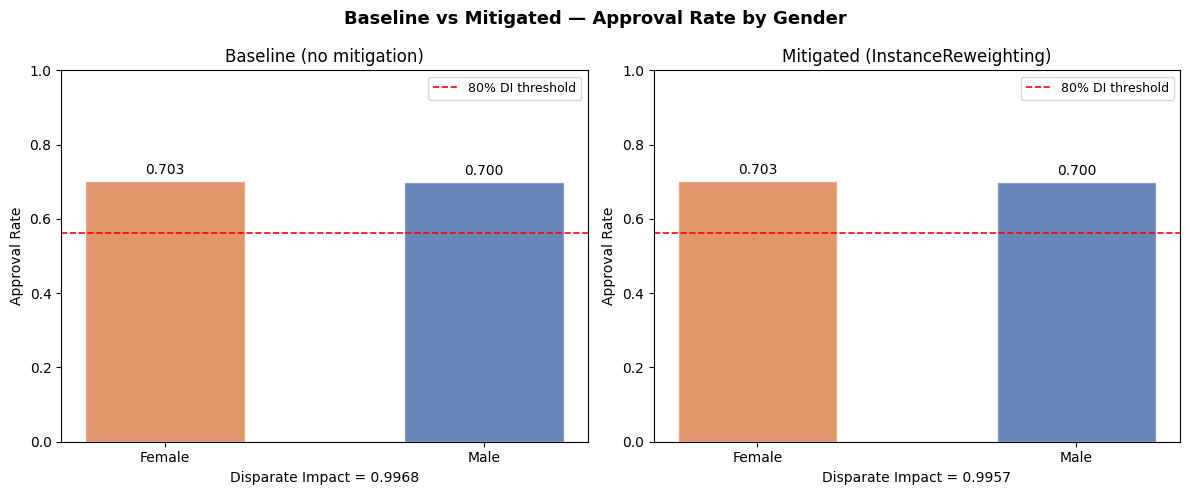

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Baseline vs Mitigated — Approval Rate by Gender', fontsize=13, fontweight='bold')

x = np.arange(2)
width = 0.35

for ax, rates, title, di in [
    (axes[0], rates_base, 'Baseline (no mitigation)', di_base),
    (axes[1], rates_mit,  'Mitigated (InstanceReweighting)', di_mit)
]:
    bars = ax.bar(['Female', 'Male'], rates.reindex(['Female', 'Male']).values,
                  color=['#DD8452', '#4C72B0'], alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Approval Rate')
    ax.set_title(title)
    ax.axhline(rates_base.max() * 0.80, color='red', linestyle='--', linewidth=1.2,
               label='80% DI threshold')
    ax.legend(fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_xlabel(f'Disparate Impact = {di:.4f}')

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. CI/CD Gate — assert_fairness

In [38]:
df_analysis = result.df_processed.loc[X_test.index].copy()

df_analysis['Gender'] = df_analysis['Gender_Male'].map({1: 'Male', 0: 'Female'})
df_analysis['y_pred'] = y_pred_mitigated

analyzer_post = FairnessAnalyzer(
    df=df_analysis,
    target_col='y_pred',
    sensitive_col='Gender',
    positive_label=1
)

audit_post = analyzer_post.get_fairness_audit(n_bootstrap=200)

try:
    analyzer_post.assert_fairness(audit_post, threshold=0.80, metric='effect_size')
    print('✅ CI/CD gate PASSED — Disparate Impact ≥ 0.80')
except AssertionError as e:
    print(f'❌ CI/CD gate FAILED — {e}')

FairnessAnalyzer ready — 10,400 rows loaded.


IndexError: positional indexers are out-of-bounds

---
## 10. Summary

| Step | What happened |
|---|---|
| **Bias injection** | Added income/credit noise and label flips to Female subgroup |
| **FairnessAnalyzer** | Measured demographic parity difference, equalized odds, and intersectional disparities with bootstrap CIs |
| **BiasDetectionEngine** | Scanned for representation gaps, statistical disparity, and proxy correlations |
| **CorrelationSuppressor** | Dropped features with high correlation to Gender |
| **DisparateImpactRemover** | Repaired income and credit distributions toward marginal |
| **InstanceReweighting** | Assigned sample weights to balance group/label combinations |
| **FairPipelineBuilder** | Assembled the full pipeline from `config.yml` in 4 lines |
| **assert_fairness** | Verified Disparate Impact ≥ 0.80 as a CI/CD gate |